# 컴퓨터 비전

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용

In [3]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 이미지에 마스크, 색깔 픽셀 적용하기

## 이미지에 마스크 씌우기 

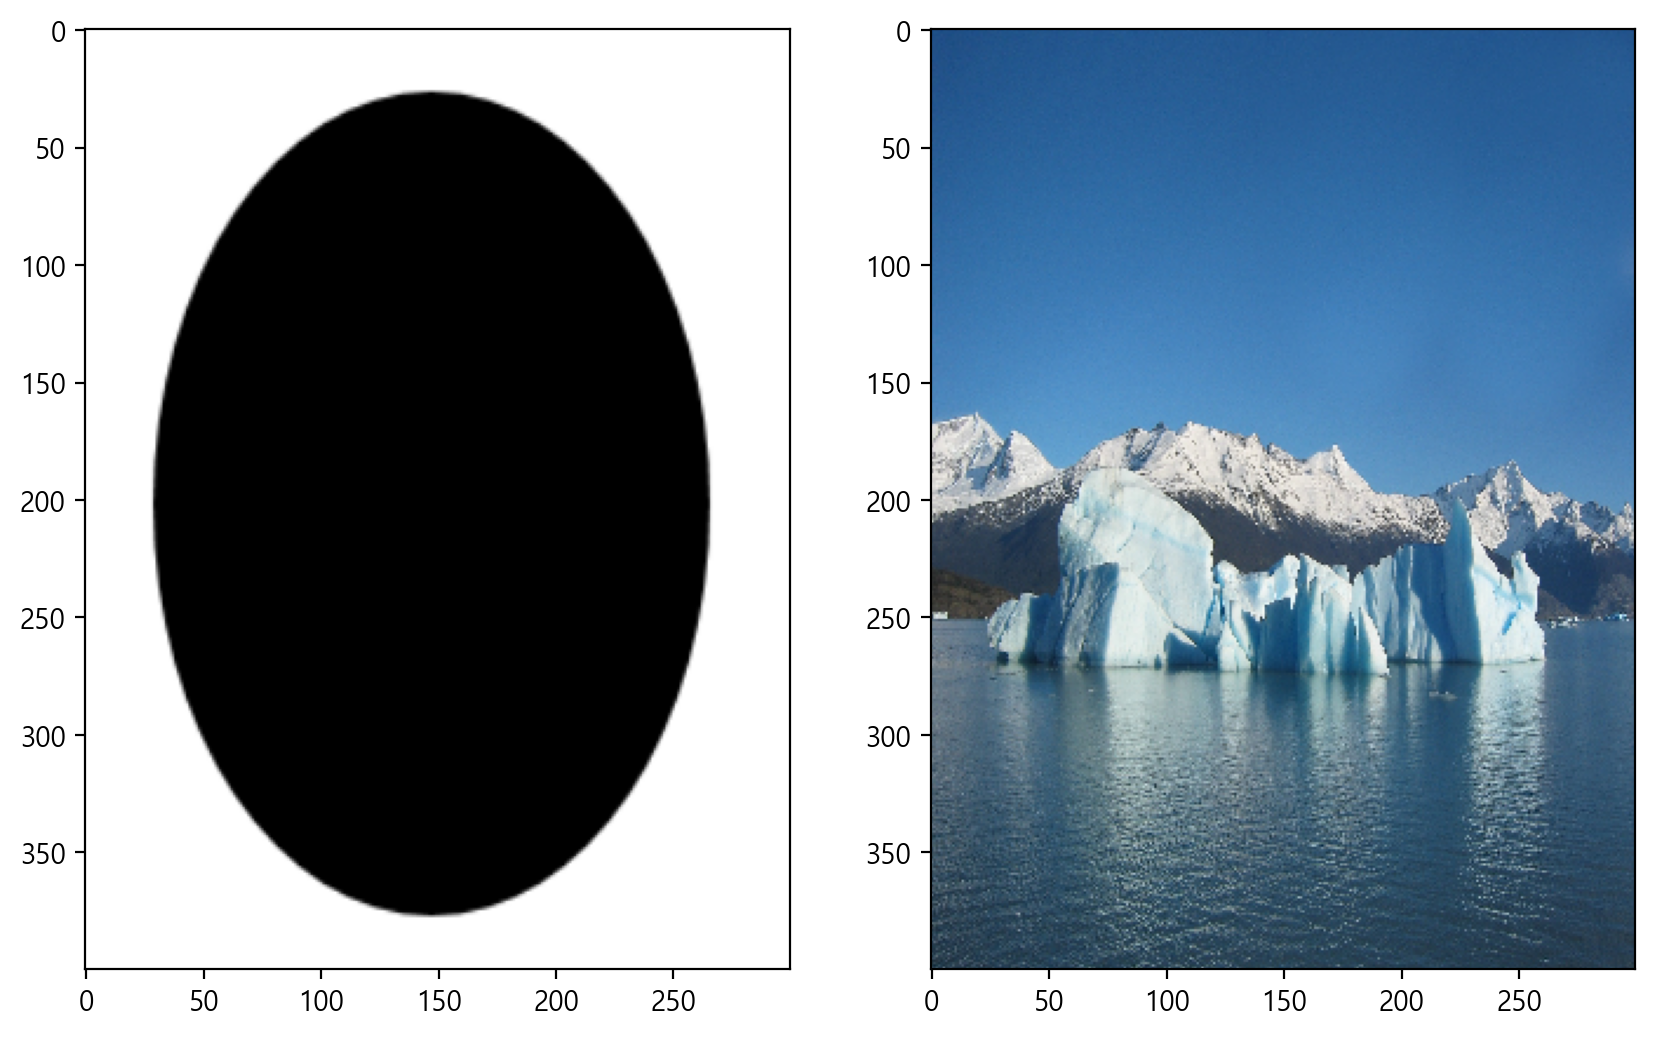

In [5]:
# 마스크로 사용될 이미지와 일반적인 이미지 화면에 출력하기 

import cv2, os
import matplotlib.pyplot as plt 

mask_image = cv2.imread(os.getcwd()+'/images/mask_circle.png', cv2.IMREAD_COLOR)
back_image = cv2.imread(os.getcwd()+'/images/iceberg.png', cv2.IMREAD_COLOR)
mask_image = cv2.cvtColor(mask_image, cv2.COLOR_BGR2RGB)
back_image = cv2.cvtColor(back_image, cv2.COLOR_BGR2RGB)
mask_image = cv2.resize(mask_image, (300,400))        # 이미지를 300x400 크기로 설정
back_image = cv2.resize(back_image, (300,400))        # 이미지를 300x400 크기로 설정 

plt.figure(figsize=(10, 10))
plt.subplot(121)
plt.imshow(mask_image)
plt.subplot(122)
plt.imshow(back_image)
plt.show()

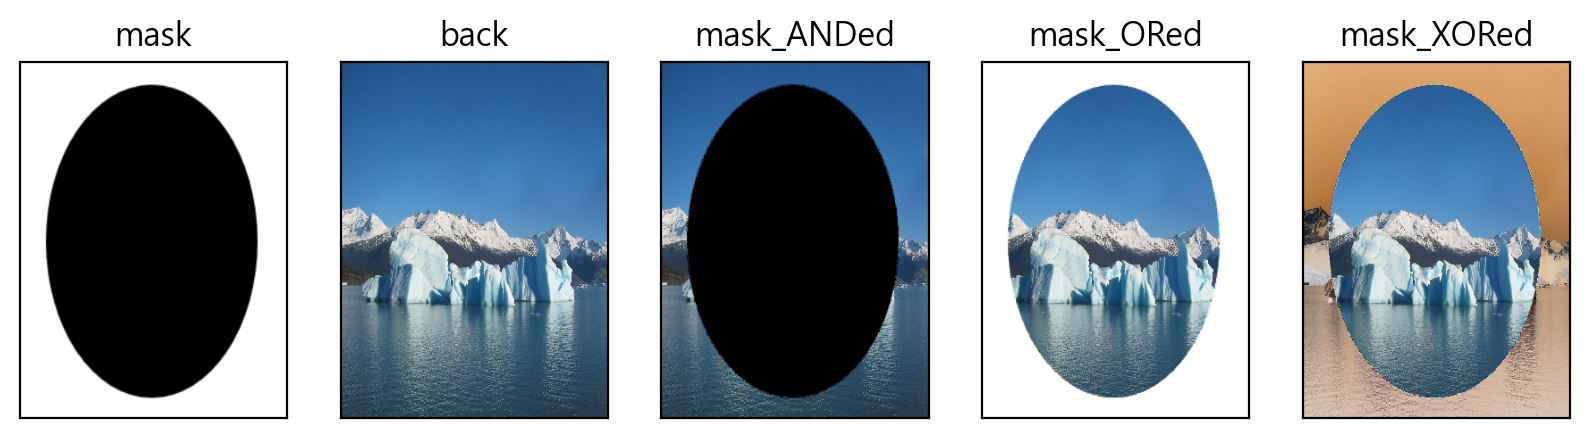

In [7]:
# OpenCV의 bitwise_and(), bitwise_or(), bitwise_xor() 함수로 이미지를 비트 단위로 연산하는 일도 가능하다.
#  - and 연산은 두 이미지의 대응되는 비트들이 모두 1인 경우에 1이 되고 그렇지 않으면 0이 된다. 
#  - or 연산은 둘 중에서 하나만 1인 경우에는 1이 된다. 
#  - not 연산은 하나의 이미지에 대해 적용하며 이 이미지의 비트들이 0은 1로, 1은 0으로 바뀌게 된다. 
#  - xor 연산은 두 이미지의 대응 비트 중에 하나만 1인 경우에 1이 된다. 

# 마스크와 비트연산(and, or, xor)을 수행한 결과를 이미지로 생성하는 예제

import cv2, os
import matplotlib.pyplot as plt 

mask_image = cv2.imread(os.getcwd()+'/images/mask_circle.png', cv2.IMREAD_COLOR)
back_image = cv2.imread(os.getcwd()+'/images/iceberg.png', cv2.IMREAD_COLOR)
mask_image = cv2.cvtColor(mask_image, cv2.COLOR_BGR2RGB)
back_image = cv2.cvtColor(back_image, cv2.COLOR_BGR2RGB)
mask_image = cv2.resize(mask_image, (300,400))        # 이미지를 300x400 크기로 설정
back_image = cv2.resize(back_image, (300,400))        # 이미지를 300x400 크기로 설정 

mask_ANDed = cv2.bitwise_and(mask_image, back_image)  # 마스크와 비트단위 AND 연산
mask_ORed = cv2.bitwise_or(mask_image, back_image)    # 마스크와 비트단위 OR 연산
mask_XORed = cv2.bitwise_xor(mask_image, back_image)  # 마스크와 비트단위 XOR 연산

plt.figure(figsize=(10, 10))
plt.subplot(151)
plt.imshow(mask_image)
plt.title("mask")
plt.xticks([])
plt.yticks([])
plt.subplot(152)
plt.imshow(back_image)
plt.title("back")
plt.xticks([])
plt.yticks([])
plt.subplot(153)
plt.imshow(mask_ANDed)
plt.title("mask_ANDed")
plt.xticks([])
plt.yticks([])
plt.subplot(154)
plt.imshow(mask_ORed)
plt.title("mask_ORed")
plt.xticks([])
plt.yticks([])
plt.subplot(155)
plt.imshow(mask_XORed)
plt.title("mask_XORed")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('mask', mask_image)    
# cv2.imshow('back', back_image)
# cv2.imshow('mask_and', mask_ANDed)
# cv2.imshow('mask_or', mask_ORed)
# cv2.imshow('mask_xor', mask_XORed)
# cv2.waitKey(0)                                       # 사용자 입력을 기다림 
# cv2.destroyAllWindows()                              # 모든 창을 없애고 프로그램 종료 

## 이미지에서 원하는 색깔 픽셀만 뽑아내기

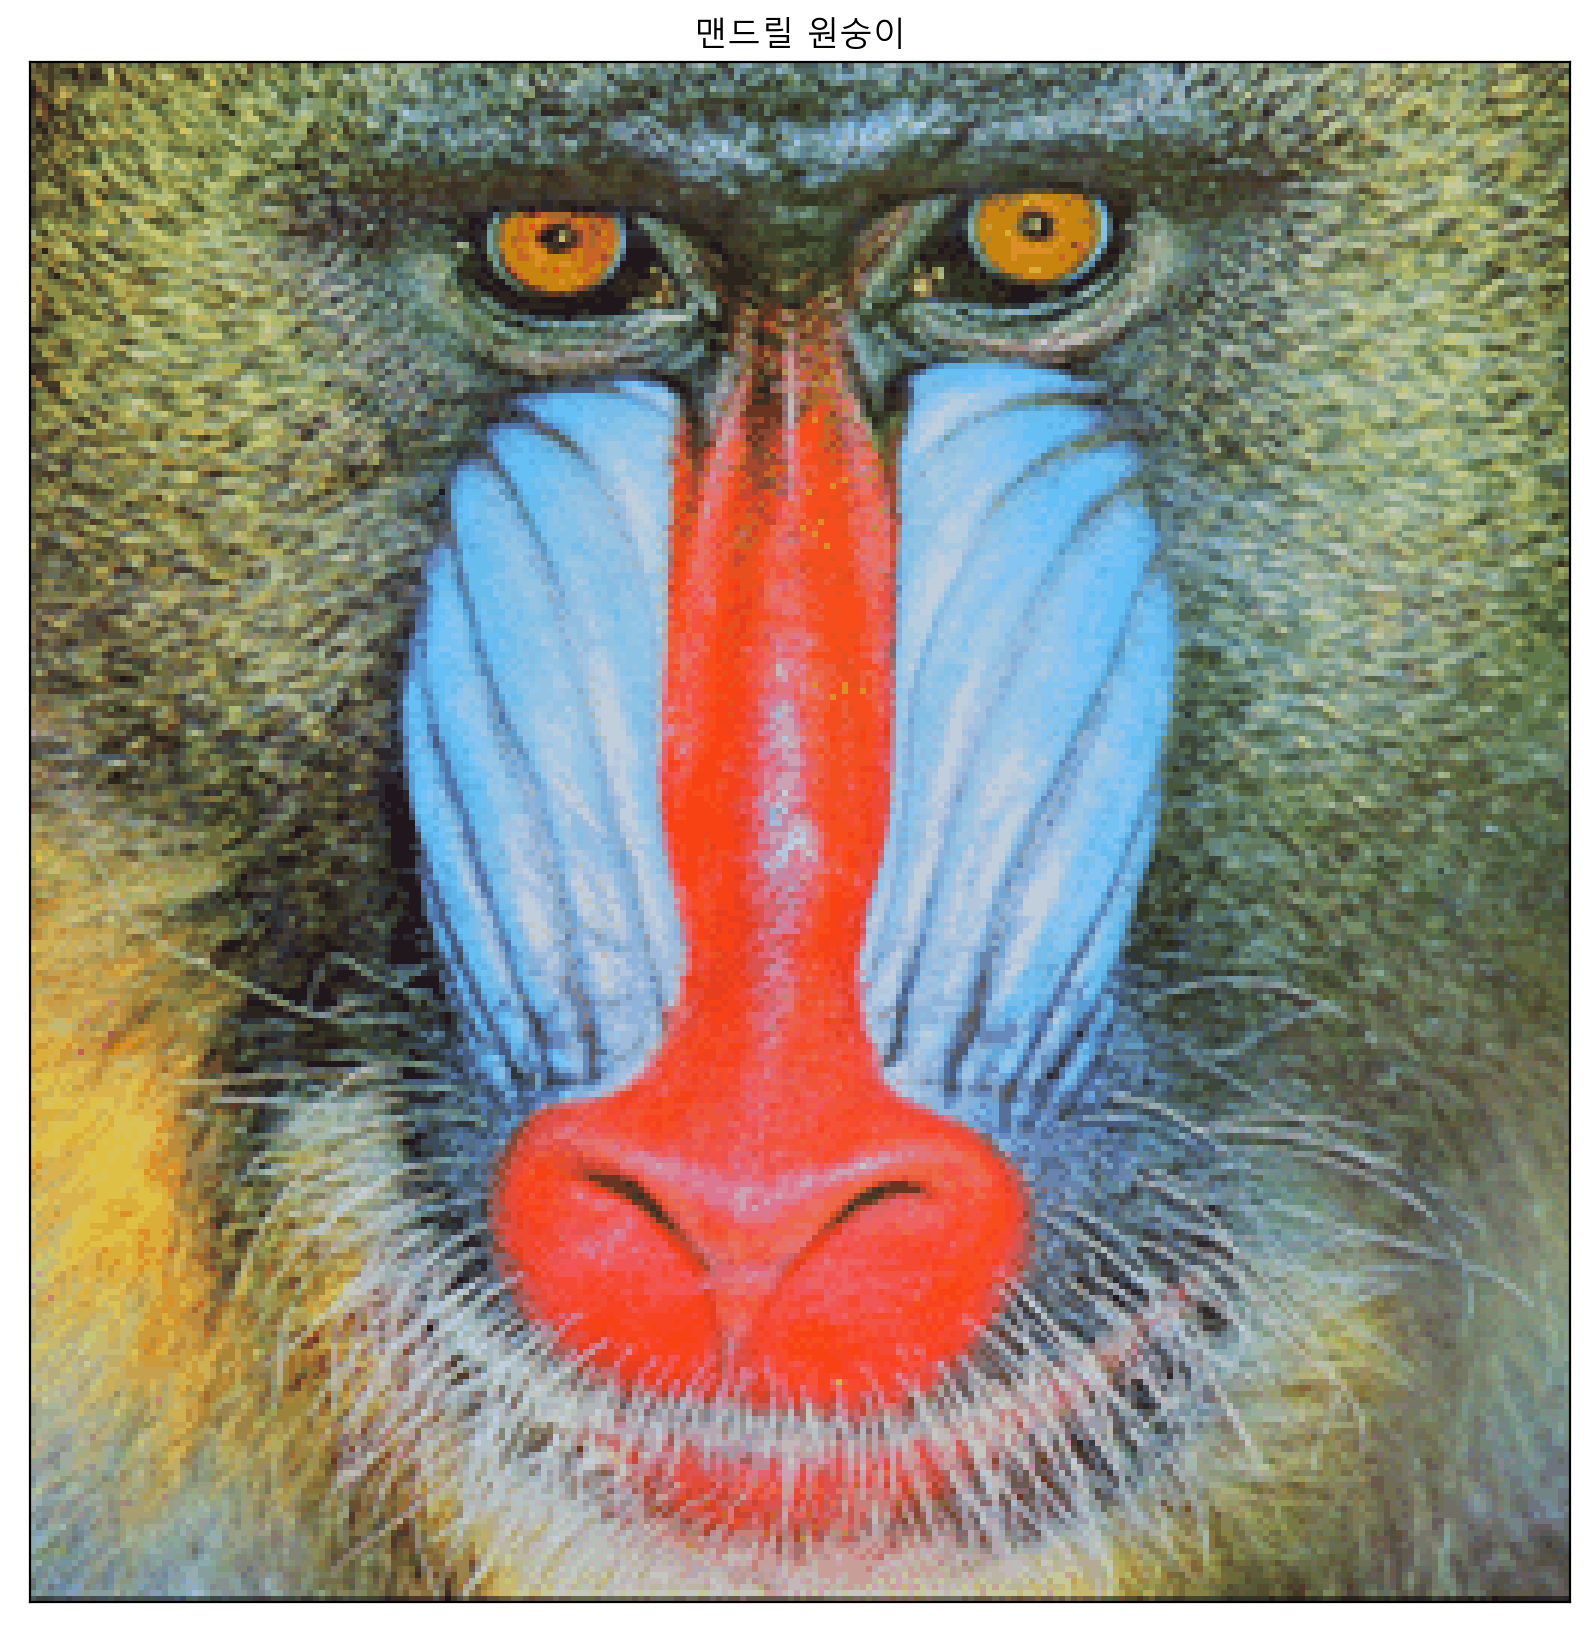

In [3]:
# 다음은 맨드릴 원숭이 이미지를 화면에 출력하기 

import cv2, os
import matplotlib.pyplot as plt 

image = cv2.imread(os.getcwd()+'/images/mandrill.png', cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("맨드릴 원숭이")
plt.xticks([])
plt.yticks([])
plt.show()

(256, 256, 3)
(256, 256, 3)
(256, 256)


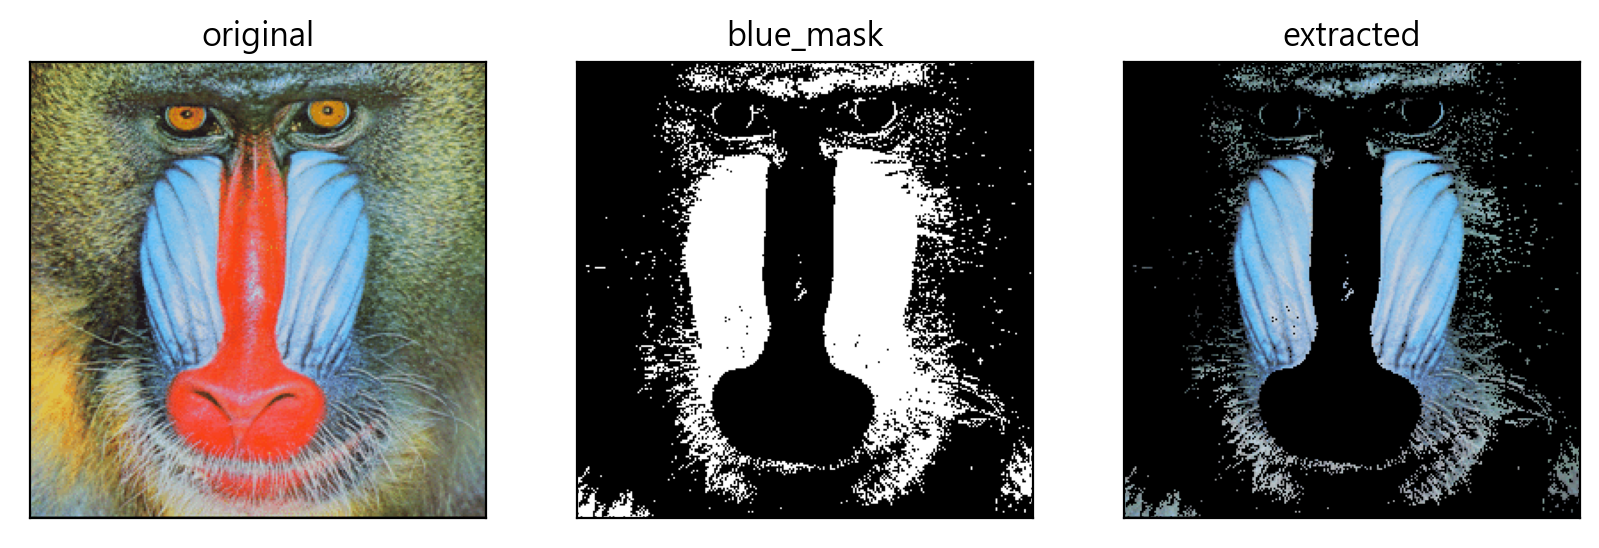

In [4]:
# OpenCV의 cvtColor() 함수를 이용하여 OpenCV의 기본 이미지 모드인 BGR 모드로 되어 있는 이미지를 HSV 모드로 바꾼다.

# OpenCV의 inRange() 함수를 이용하여 80~130도 범위에 있는 픽셀을 찾아낸다.
#  - 80 ~ 130도 범위에 있는 픽셀들은 1(흰색), 그렇지 않은 픽셀은 0(검은색)으로 표시한 이미지를 뽑아준다. 

# bitwise_and(src1, src2[, dst[, mask]])

# 다음은 맨드릴 원숭이 이미지에서 푸른색 픽셀만 추출하는 예제 

import cv2, os  
import numpy as np 
import matplotlib.pyplot as plt

image = cv2.imread(os.getcwd()+'/images/mandrill.png', cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)           # RGB 모드로 변환
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)           # HSV 모드로 변환 

blue_low = np.array([80, 0, 0])                              # 푸른색의 아래쪽 경계를 색상 80
blue_high = np.array([130, 255, 255])                        # 푸른색의 위쪽 경계를 색상 130
blue_mask = cv2.inRange(image_hsv, blue_low, blue_high)      # 푸른색 픽셀 선택  
blue_mask_rgb = cv2.cvtColor(blue_mask, cv2.COLOR_BGR2RGB)   # RGB 모드로 변환  
print(image_hsv.shape)                                       # (256, 256, 3) 
print(image_rgb.shape)                                       # (256, 256, 3) 
print(blue_mask.shape)                                       # (256, 256) 
extracted = cv2.bitwise_and(image_rgb, image_rgb, mask=blue_mask) # cv2.bitwise_and 연산 

plt.figure(figsize=(10, 10))
plt.subplot(131)
plt.imshow(image_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(blue_mask_rgb)
plt.title("blue_mask")
plt.xticks([])
plt.yticks([])
plt.subplot(133)
plt.imshow(extracted)
plt.title("extracted")
plt.xticks([])
plt.yticks([])
plt.show()

In [5]:
# OpenCV의 cvtColor() 함수를 이용하여 OpenCV의 기본 이미지 모드인 BGR 모드로 되어 있는 이미지를 HSV 모드로 바꾼다.

# OpenCV의 inRange() 함수를 이용하여 80~130도 범위에 있는 픽셀을 찾아낸다.
#  - 80 ~ 130도 범위에 있는 픽셀들은 1(흰색), 그렇지 않은 픽셀은 0(검은색)으로 표시한 이미지를 뽑아준다. 

# bitwise_and(src1, src2[, dst[, mask]])

# 다음은 맨드릴 원숭이 이미지에서 푸른색 픽셀만 추출하는 예제 

# import cv2 
# import numpy as np 

# image = cv2.imread(os.getcwd()+'/images/mandrill.png', cv2.IMREAD_COLOR)
# image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)        # HSV 모드로 변환 
# print(image_hsv.shape)                                    # (256, 256, 3) 

# blue_low = np.array([80, 0, 0])
# blue_high = np.array([130, 255, 255])
# blue_mask = cv2.inRange(image_hsv, blue_low, blue_high)   # 푸른색 픽셀 선택  

# cv2.imshow('original', image)                             # 원본 이미지 
# cv2.imshow('blue_mask', blue_mask)                        # 푸른색 마스크 

# print(image.shape)                                        # (256, 256, 3) 
# print(blue_mask.shape)                                    # (256, 256)
# extracted = cv2.bitwise_and(image, image, mask=blue_mask) # cv2.bitwise_and 연산 
# cv2.imshow('extracted', extracted)                        # 원본이미지에서 푸른색 픽셀만 추출한 이미지 

# cv2.waitKey(0)                                            # 사용자 입력을 기다림 
# cv2.destroyAllWindows()                                   # 모든 창을 없애고 프로그램 종료 